# Batch Gradient Descent

## Learning Objectives

By the end of this notebook you will be able to:

1. **Explain** why gradient descent is preferred over the Normal Equation for large-scale problems
2. **Define** the hypothesis function, cost function, and their matrix forms
3. **Derive** the batch gradient descent update rule from first principles using the chain rule
4. **Describe** the training and prediction phases step by step
5. **Implement** batch gradient descent and prediction in NumPy

## Problem Statement

In supervised learning with a linear model we seek parameters $\boldsymbol{\theta}$ such that the predicted values $\hat{y}^{(i)}$ are as close as possible to the true targets $y^{(i)}$ across all $m$ training examples. The quality of fit is measured by the **mean squared error cost function**:

$\displaystyle J(\boldsymbol{\theta}) = \frac{1}{2m}\sum_{i=1}^{m}\bigl(\hat{y}^{(i)} - y^{(i)}\bigr)^2$

Minimising $J$ directly is non-trivial: the parameter space is continuous and $(n+1)$-dimensional, making exhaustive search intractable. We need a principled iterative strategy that walks $\boldsymbol{\theta}$ downhill on the cost surface.

### Why Not Solve Analytically?

Linear regression has a closed-form solution called the **Normal Equation**:

$\displaystyle \boldsymbol{\theta}^* = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$

This works — but it has a critical weakness: computing $(\mathbf{X}^\top \mathbf{X})^{-1}$ requires matrix inversion, which costs $O(n^3)$ where $n$ is the number of features.

### When to Use Which Method

| Scenario | Normal Equation | Gradient Descent |
|:---|:---|:---|
| Small $n$ (< 1 000 features) | Fast, exact | Works but overkill |
| Large $n$ (> 10 000 features) | Extremely slow / infeasible | Scales well |
| Non-linear models (logistic regression, neural networks) | No closed form exists | Universal — works for any differentiable $J$ |
| Streaming / online data | Must recompute from scratch | Easy to update incrementally |

### The Core Idea

Instead of solving for the minimum in one shot, gradient descent finds it iteratively: start anywhere, look at the slope of $J$ at the current point, and take a small step downhill. Repeat until the bottom.

**Why moving opposite the gradient decreases $J$ — Taylor expansion:**

The first-order Taylor expansion of $J$ around the current $\boldsymbol{\theta}$:

$\displaystyle J(\boldsymbol{\theta} + \Delta\boldsymbol{\theta}) \approx J(\boldsymbol{\theta}) + \nabla_{\boldsymbol{\theta}} J^\top \Delta\boldsymbol{\theta}$

For the cost to decrease we need $\nabla_{\boldsymbol{\theta}} J^\top \Delta\boldsymbol{\theta} < 0$. Setting $\Delta\boldsymbol{\theta} = -\alpha \nabla_{\boldsymbol{\theta}} J$ guarantees this, giving the update rule:

$\displaystyle \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \alpha \underbrace{\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta})}_{\text{direction of steepest ascent}}$

Each step only costs $O(mn)$ — linear in both the number of examples and features — making it tractable at any scale.

> At each iteration, Batch Gradient Descent computes the exact gradient of $J$ over the **entire** training set and moves $\boldsymbol{\theta}$ a step $\alpha$ in the direction that decreases cost the most.

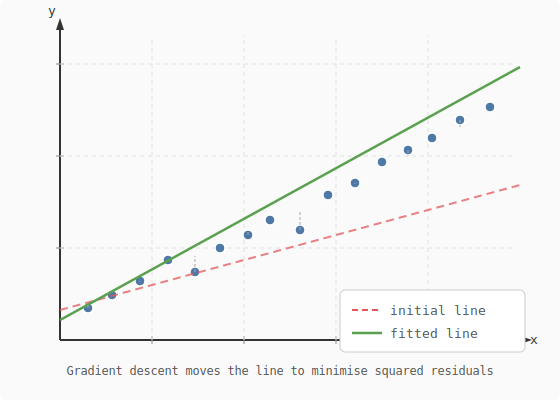

In [1]:
from IPython.display import SVG, display

svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="560" height="400" font-family="monospace" font-size="13">

  <!-- background -->
  <rect width="560" height="400" fill="#fafafa" rx="8"/>

  <!-- axes -->
  <line x1="60" y1="340" x2="520" y2="340" stroke="#333" stroke-width="2"/>
  <line x1="60" y1="340" x2="60"  y2="30"  stroke="#333" stroke-width="2"/>

  <!-- axis arrows -->
  <polygon points="520,336 520,344 532,340" fill="#333"/>
  <polygon points="56,30 64,30 60,18"       fill="#333"/>

  <!-- axis labels -->
  <text x="530" y="344" fill="#333">x</text>
  <text x="48"  y="15"  fill="#333">y</text>

  <!-- tick marks x -->
  <line x1="152" y1="336" x2="152" y2="344" stroke="#888" stroke-width="1"/>
  <line x1="244" y1="336" x2="244" y2="344" stroke="#888" stroke-width="1"/>
  <line x1="336" y1="336" x2="336" y2="344" stroke="#888" stroke-width="1"/>
  <line x1="428" y1="336" x2="428" y2="344" stroke="#888" stroke-width="1"/>

  <!-- tick marks y -->
  <line x1="56" y1="248" x2="64" y2="248" stroke="#888" stroke-width="1"/>
  <line x1="56" y1="156" x2="64" y2="156" stroke="#888" stroke-width="1"/>
  <line x1="56" y1="64"  x2="64" y2="64"  stroke="#888" stroke-width="1"/>

  <!-- grid (light) -->
  <line x1="152" y1="340" x2="152" y2="35" stroke="#e0e0e0" stroke-width="1" stroke-dasharray="4,4"/>
  <line x1="244" y1="340" x2="244" y2="35" stroke="#e0e0e0" stroke-width="1" stroke-dasharray="4,4"/>
  <line x1="336" y1="340" x2="336" y2="35" stroke="#e0e0e0" stroke-width="1" stroke-dasharray="4,4"/>
  <line x1="428" y1="340" x2="428" y2="35" stroke="#e0e0e0" stroke-width="1" stroke-dasharray="4,4"/>
  <line x1="60"  y1="248" x2="515" y2="248" stroke="#e0e0e0" stroke-width="1" stroke-dasharray="4,4"/>
  <line x1="60"  y1="156" x2="515" y2="156" stroke="#e0e0e0" stroke-width="1" stroke-dasharray="4,4"/>
  <line x1="60"  y1="64"  x2="515" y2="64"  stroke="#e0e0e0" stroke-width="1" stroke-dasharray="4,4"/>

  <!-- ── data points (filled circles) ── -->
  <!-- roughly follow y ≈ 0.55x + 30 in SVG coords (y-axis flipped) -->
  <circle cx="88"  cy="308" r="5" fill="#4e79a7" stroke="#fff" stroke-width="1.5"/>
  <circle cx="112" cy="295" r="5" fill="#4e79a7" stroke="#fff" stroke-width="1.5"/>
  <circle cx="140" cy="281" r="5" fill="#4e79a7" stroke="#fff" stroke-width="1.5"/>
  <circle cx="168" cy="260" r="5" fill="#4e79a7" stroke="#fff" stroke-width="1.5"/>
  <circle cx="195" cy="272" r="5" fill="#4e79a7" stroke="#fff" stroke-width="1.5"/>
  <circle cx="220" cy="248" r="5" fill="#4e79a7" stroke="#fff" stroke-width="1.5"/>
  <circle cx="248" cy="235" r="5" fill="#4e79a7" stroke="#fff" stroke-width="1.5"/>
  <circle cx="270" cy="220" r="5" fill="#4e79a7" stroke="#fff" stroke-width="1.5"/>
  <circle cx="300" cy="230" r="5" fill="#4e79a7" stroke="#fff" stroke-width="1.5"/>
  <circle cx="328" cy="195" r="5" fill="#4e79a7" stroke="#fff" stroke-width="1.5"/>
  <circle cx="355" cy="183" r="5" fill="#4e79a7" stroke="#fff" stroke-width="1.5"/>
  <circle cx="382" cy="162" r="5" fill="#4e79a7" stroke="#fff" stroke-width="1.5"/>
  <circle cx="408" cy="150" r="5" fill="#4e79a7" stroke="#fff" stroke-width="1.5"/>
  <circle cx="432" cy="138" r="5" fill="#4e79a7" stroke="#fff" stroke-width="1.5"/>
  <circle cx="460" cy="120" r="5" fill="#4e79a7" stroke="#fff" stroke-width="1.5"/>
  <circle cx="490" cy="107" r="5" fill="#4e79a7" stroke="#fff" stroke-width="1.5"/>

  <!-- ── initial (random) line — dashed, red ── -->
  <!-- passes through (60, 295) → (520, 200): steep but wrong slope -->
  <line x1="60" y1="310" x2="520" y2="185"
        stroke="#e15759" stroke-width="2" stroke-dasharray="8,5" opacity="0.75"/>

  <!-- ── converged (fitted) line — solid, green ── -->
  <!-- best-fit y_svg = 340 - (0.55*(x_svg-60) + 20), so at x=60: 320, x=520: 67 -->
  <line x1="60" y1="320" x2="520" y2="67"
        stroke="#59a14f" stroke-width="2.5"/>

  <!-- ── residual lines from points to fitted line (thin grey) ── -->
  <!-- fitted y_svg at each cx: y = 320 - 0.55*(cx-60) -->
  <line x1="88"  cy1="308" x2="88"  y1="308" y2="305" stroke="#aaa" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="140" y1="281" x2="140" y2="282" stroke="#aaa" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="195" y1="272" x2="195" y2="256" stroke="#aaa" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="248" y1="235" x2="248" y2="230" stroke="#aaa" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="300" y1="230" x2="300" y2="210" stroke="#aaa" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="355" y1="183" x2="355" y2="184" stroke="#aaa" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="408" y1="150" x2="408" y2="156" stroke="#aaa" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="460" y1="120" x2="460" y2="127" stroke="#aaa" stroke-width="1" stroke-dasharray="3,2"/>

  <!-- ── legend ── -->
  <rect x="340" y="290" width="185" height="62" fill="white" stroke="#ccc" rx="5"/>
  <line x1="352" y1="310" x2="382" y2="310" stroke="#e15759" stroke-width="2" stroke-dasharray="6,4"/>
  <text x="390" y="315" fill="#555">initial line</text>
  <line x1="352" y1="333" x2="382" y2="333" stroke="#59a14f" stroke-width="2.5"/>
  <text x="390" y="338" fill="#555">fitted line</text>

  <!-- title -->
  <text x="280" y="375" text-anchor="middle" fill="#555" font-size="12">
    Gradient descent moves the line to minimise squared residuals
  </text>
</svg>
"""

display(SVG(svg))

# Hypothesis Function

The hypothesis $h_{\boldsymbol{\theta}}$ maps an input vector $x$ to a predicted scalar output $\hat{y}$. For linear regression it is a **linear function of the parameters**:

$\displaystyle h_{\boldsymbol{\theta}}(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n = \sum_{k=0}^{n} \theta_k x_k$

where $x_0 = 1$ is an augmented bias feature so the intercept $\theta_0$ fits neatly into the same dot product.

**In vector form**, defining $x = [1,\, x_1,\, x_2,\, \ldots,\, x_n]^\top \in \mathbb{R}^{n+1}$:

$\displaystyle h_{\boldsymbol{\theta}}(x) = \boldsymbol{\theta}^\top x$

**For training example $i$**, the predicted value is:

$\displaystyle \hat{y}^{(i)} = h_{\boldsymbol{\theta}}(x^{(i)}) = \boldsymbol{\theta}^\top x^{(i)}$

| Parameter | Geometric role |
|:---|:---|
| $\theta_0$ | Intercept — shifts the hyperplane up or down |
| $\theta_1, \ldots, \theta_n$ | Slopes — how much $\hat{y}$ changes per unit increase in each feature |

Stacking all $m$ predictions at once gives the compact matrix form used throughout the derivation:

$\displaystyle \hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\theta} \in \mathbb{R}^m$

# Derivation of the Batch Gradient Descent Update Rule

## Overview

| Step | What we do | Why |
|------|-----------|-----|
| 1. Setup | Write the dataset as matrices $X$, $\mathbf{y}$, $\theta$; define $\hat{y}^{(i)}$ | Compact notation that scales to $n$ features |
| 2. Cost function | Define $J(\theta)$ as the mean squared error over all $m$ examples | Gives a single scalar to minimise |
| 3. Differentiate | Apply the chain rule to get $\frac{\partial J}{\partial \theta_j}$ for every $j$ | The gradient tells us which direction increases $J$ |
| 4. Update rule | Move $\theta$ a small step $\alpha$ opposite to the gradient | One step downhill on the cost surface |
| 5. Vectorise | Rewrite the update as $\theta := \theta - \frac{\alpha}{m} X^\top(\hat{\mathbf{y}} - \mathbf{y})$ | Efficient to implement; one matrix expression covers all $j$ |
| 6. Converge | Repeat until $\Delta J < \epsilon$ | $J$ is convex, so we reach the global minimum |

---

## 1. Setup

We have $m$ training examples each with $n$ features.

**Dataset in matrix form:**

Each row is one training example. We prepend a column of ones to absorb the intercept $\theta_0$.

$\displaystyle X = \begin{bmatrix} 1 & x_1^{(1)} & x_2^{(1)} & \cdots & x_n^{(1)} \\ 1 & x_1^{(2)} & x_2^{(2)} & \cdots & x_n^{(2)} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_1^{(m)} & x_2^{(m)} & \cdots & x_n^{(m)} \end{bmatrix} \in \mathbb{R}^{m \times (n+1)}$

$\displaystyle \mathbf{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \end{bmatrix} \in \mathbb{R}^{m}$

$\displaystyle \theta = \begin{bmatrix} \theta_0 \\ \theta_1 \\ \vdots \\ \theta_n \end{bmatrix} \in \mathbb{R}^{n+1}$

**Hypothesis** — the predicted value for example $i$:

$\displaystyle \hat{y}^{(i)} = h_\theta(x^{(i)}) = \theta^\top x^{(i)} = \sum_{k=0}^{n} \theta_k x_k^{(i)}, \qquad \text{where } x_0^{(i)} = 1$

Stacking predictions for all examples:

$\displaystyle \hat{\mathbf{y}} = X\theta = \begin{bmatrix} \hat{y}^{(1)} \\ \hat{y}^{(2)} \\ \vdots \\ \hat{y}^{(m)} \end{bmatrix} = \begin{bmatrix} \theta_0 + \theta_1 x_1^{(1)} + \cdots + \theta_n x_n^{(1)} \\ \theta_0 + \theta_1 x_1^{(2)} + \cdots + \theta_n x_n^{(2)} \\ \vdots \\ \theta_0 + \theta_1 x_1^{(m)} + \cdots + \theta_n x_n^{(m)} \end{bmatrix}$

---

## 2. Cost Function

$\displaystyle J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)^2 = \frac{1}{2m} \| \hat{\mathbf{y}} - \mathbf{y} \|^2 = \frac{1}{2m} \| X\theta - \mathbf{y} \|^2$

The $\frac{1}{2}$ is a convenience factor — it cancels the $2$ produced by differentiating the square.

---

## 3. Differentiate

Let $e^{(i)} = \hat{y}^{(i)} - y^{(i)}$ denote the residual for example $i$.

**Chain rule applied to the sum:**

$\displaystyle \begin{aligned} \frac{\partial J}{\partial \theta_j} &= \frac{1}{2m} \sum_{i=1}^{m} \frac{\partial}{\partial \theta_j} \left(e^{(i)}\right)^2 \\[6pt] &= \frac{1}{2m} \sum_{i=1}^{m} 2\, e^{(i)} \cdot \frac{\partial e^{(i)}}{\partial \theta_j} \\[6pt] &= \frac{1}{m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right) \cdot \frac{\partial \hat{y}^{(i)}}{\partial \theta_j} \end{aligned}$

**Evaluate the inner partial** — only the $j$-th term in $\sum_k \theta_k x_k^{(i)}$ survives:

$\displaystyle \frac{\partial \hat{y}^{(i)}}{\partial \theta_j} = x_j^{(i)} \qquad (x_0^{(i)} = 1 \text{ for } j=0)$

Therefore, for every $j \in \{0, 1, \ldots, n\}$:

$\displaystyle \boxed{ \frac{\partial J}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right) x_j^{(i)}}$

**Gradient vector** (stacking all partials):

$\displaystyle \nabla_\theta J = \frac{1}{m} X^\top (\hat{\mathbf{y}} - \mathbf{y}) = \frac{1}{m} X^\top (X\theta - \mathbf{y}) \in \mathbb{R}^{n+1}$

---

## 4. Update Rule

Starting from any initial $\theta$, **simultaneously** update all $n+1$ parameters:

$\displaystyle \theta_j := \theta_j - \alpha \frac{\partial J}{\partial \theta_j} \qquad \text{for } j = 0, 1, \ldots, n$

$\displaystyle \theta_j := \theta_j - \frac{\alpha}{m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right) x_j^{(i)}$

where $\alpha > 0$ is the **learning rate**.

---

## 5. Vectorised Form

All parameters updated in one expression:

$\displaystyle \boxed{\theta := \theta - \frac{\alpha}{m} X^\top (\hat{\mathbf{y}} - \mathbf{y})}$

---

## 6. Convergence

Repeat the simultaneous update until:

$\displaystyle \left| J(\theta^{\text{new}}) - J(\theta^{\text{old}}) \right| < \epsilon$

Because $J$ is convex in $\theta$ (a quadratic bowl in $\mathbb{R}^{n+1}$), gradient descent converges to the **global minimum** for any sufficiently small $\alpha$.

# Training Phase

Training finds the $\boldsymbol{\theta}$ that minimises $J$. The steps below repeat every iteration until convergence.

---

**1. Initialise parameters**

Set $\boldsymbol{\theta} = \mathbf{0}$ (or small random values). This is the starting point on the cost surface.

---

**2. Compute predictions**

Run the hypothesis over every training example to get the predicted vector:

$\displaystyle \hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\theta}$

---

**3. Compute the cost**

Measure how far the predictions are from the true targets:

$\displaystyle J(\boldsymbol{\theta}) = \frac{1}{2m}\|\hat{\mathbf{y}} - \mathbf{y}\|^2$

---

**4. Compute the gradient**

Calculate the direction and magnitude of the steepest ascent on $J$:

$\displaystyle \nabla_{\boldsymbol{\theta}}\,J = \frac{1}{m}\,\mathbf{X}^\top(\hat{\mathbf{y}} - \mathbf{y})$

---

**5. Update parameters**

Take a step of size $\alpha$ in the direction that decreases $J$:

$\displaystyle \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \alpha\,\nabla_{\boldsymbol{\theta}}\,J$

---

**6. Check convergence**

Stop when the cost stops decreasing appreciably:

$\displaystyle \bigl|J(\boldsymbol{\theta}^{\text{new}}) - J(\boldsymbol{\theta}^{\text{old}})\bigr| < \epsilon$

Otherwise go back to step 2.

---

**7. Use the learned parameters**

The final $\boldsymbol{\theta}$ defines the trained model. Predict on new input $\mathbf{x}$:

$\displaystyle \hat{y} = h_{\boldsymbol{\theta}}(\mathbf{x}) = \mathbf{x}^\top \boldsymbol{\theta}$

# Prediction Phase

Given the learned parameters $\boldsymbol{\theta}^*$ from training, predicting on new data is a single forward pass — no iteration required.

---

**1. Receive new input**

Obtain a new example with $n$ feature values:

$\displaystyle x_{\text{new}} = [x_1,\, x_2,\, \ldots,\, x_n]^\top \in \mathbb{R}^n$

---

**2. Augment with bias term**

Prepend $x_0 = 1$ to absorb the intercept $\theta_0$:

$\displaystyle x_{\text{new}} \leftarrow [1,\, x_1,\, x_2,\, \ldots,\, x_n]^\top \in \mathbb{R}^{n+1}$

---

**3. Compute prediction**

Apply the learned hypothesis:

$\displaystyle \hat{y}_{\text{new}} = {\boldsymbol{\theta}^*}^\top x_{\text{new}} = \theta_0^* + \theta_1^* x_1 + \cdots + \theta_n^* x_n$

For a batch of $p$ new examples stacked into $\mathbf{X}_{\text{new}} \in \mathbb{R}^{p \times (n+1)}$:

$\displaystyle \hat{\mathbf{y}}_{\text{new}} = \mathbf{X}_{\text{new}}\,\boldsymbol{\theta}^* \in \mathbb{R}^p$

---

**4. Return prediction**

Output $\hat{y}_{\text{new}}$ (or $\hat{\mathbf{y}}_{\text{new}}$ for a batch) as the model's response. No retraining or parameter update occurs.

In [ ]:
import numpy as np


def train_batch_gradient_descent(X, y, alpha=0.01, n_iters=1000, epsilon=1e-6):
    """
    Inputs
    ------
    X       : np.ndarray, shape (m, n+1)  — design matrix with bias column (x_0 = 1) prepended
    y       : np.ndarray, shape (m,)      — target values
    alpha   : float                       — learning rate (step size per iteration)
    n_iters : int                         — maximum number of gradient descent iterations
    epsilon : float                       — convergence threshold; stop when all |grad_j| < epsilon

    Output
    ------
    theta        : np.ndarray, shape (n+1,)  — learned parameter vector θ*
    cost_history : list[float]               — cost J(θ) recorded after each iteration
    """
    m = len(y)

    # Step 1 — initialise parameters
    theta = np.zeros(X.shape[1])
    cost_history = []

    for _ in range(n_iters):
        # Step 2 — compute predictions
        y_hat = X @ theta

        # Step 3 — compute cost
        cost = (1 / (2 * m)) * np.sum((y_hat - y) ** 2)
        cost_history.append(cost)

        # Step 4 — compute gradient
        grad = (1 / m) * X.T @ (y_hat - y)

        # Step 5 — update parameters
        theta = theta - alpha * grad

        # Step 6 — check convergence: gradient vector ≈ 0 means we are at a stationary point
        if np.allclose(grad, 0, atol=epsilon):
            break

    # Step 7 — return learned parameters
    return theta, cost_history


def predict_batch_gradient_descent(X_new, theta):
    """
    Inputs
    ------
    X_new : np.ndarray, shape (p, n+1)  — new examples with bias column (x_0 = 1) prepended
    theta : np.ndarray, shape (n+1,)    — learned parameter vector returned by train_batch_gradient_descent

    Output
    ------
    y_hat : np.ndarray, shape (p,)  — predicted values for each of the p examples
    """
    return X_new @ theta